# tf.data数据处理

## 【章节目标】
- 了解tf.data模块的功能
- 掌握tf.data创建数据集的方法
- 掌握tf.data常用功能函数的使用
- 掌握TFRecord数据集的制作和使用
- 掌握经典数据集的加载方法
- 掌握自定义数据集的创建方法

## 【章节内容】
### tf.data.Dataset基本使用
- 面对一堆格式不一的原始数据文件？
- 读入程序的过程往往十分繁琐？
- 运行的效率上不尽如人意？

TensorFlow 提供了 tf.data 这一模块，包括了一套灵活的数据集构建 API，能够帮助我们快速、高效地构建数据输入的流水线 ，尤其适用于数据量巨大的场景。

tf.data模块主要包含三个Dataset类：

- tf.data.Dataset类
- tf.data.TFRecordDataset类
- tf.data.TextLineDataset类

#### 1）tf.data.Dataset简介
- tf.data 的核心是 tf.data.Dataset 类，提供了对数据集的高层封装。
- tf.data.Dataset 由一系列的可迭代访问的元素（element）组成，每个元素包含一个或多个张量。Dataset可以看作是相同类型“元素”的有序列表。
- 比如说，对于一个由图像组成的数据集，每个元素可以是一个形状为 长×宽×通道数的图片张量，也可以是由图片张量和图片标签张量组成的元组（Tuple）。

#### 2）tf.data.Dataset创建数据集
tf.data.Dataset 类创建数据集，对数据集实例化。最常用的如：

- tf.data.Dataset.from_tensors() ：创建Dataset对象， 合并输入并返回具有单个元素的数据集。
- tf.data.Dataset.from_tensor_slices() ：创建一个Dataset对象，输入可以是一个或者多个 tensor，若是多个 tensor，需要以元组或者字典等形式组装起来。
- tf.data.Dataset. from_generator() ：迭代生成所需的数据集，一般数据量较大时使用。

**注意：Dataset可以看作是相同类型“元素”的有序列表。在实际使用时，单个“元素”可以是向量，也可以是字符串、图片，甚至是tuple或者dict**

#### 3）from_tensors和from_tensor_slices区别
- from_tensors() 函数会把传入的tensor当做一个元素
- 但是from_tensor_slices() 会把传入的tensor第0维的大小当做元素个数。

from_tensors()在形式上与from_tensor_slices()很相似，但其实from_tensors()方法出场频率上比from_tensor_slices()差太多，因为from_tensor_slices()的功能更加符合实际需求，且返回的TensorSliceDataset对象也提供更多的数据处理功能。

In [1]:
import tensorflow as tf
t = tf.constant([[1, 2], [3, 4]])
ds1 = tf.data.Dataset.from_tensors(t)
ds1

2026-04-03 12:39:07.331868: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-03 12:39:07.332023: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-03 12:39:07.339277: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-03 12:39:10.778710: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.


<_TensorDataset element_spec=TensorSpec(shape=(2, 2), dtype=tf.int32, name=None)>

In [4]:
for line in ds1:
    print(line) #整个tensor为一个元素
    break

tf.Tensor(
[[1 2]
 [3 4]], shape=(2, 2), dtype=int32)


In [5]:
len(ds1) #一个元素

1

In [6]:
t = tf.constant([[1, 2], [3, 4]])
ds2 = tf.data.Dataset.from_tensor_slices(t)
for line in ds2:
    print(line) #第0维是元素个数
    break

tf.Tensor([1 2], shape=(2,), dtype=int32)


In [7]:
len(ds2)

2

In [9]:
import numpy as np
dataset3 = tf.data.Dataset.from_tensors({
    "a": np.zeros(shape = (10, 5, 2), dtype = np.float32),
    "b": np.zeros(shape = (10, 5, 3), dtype = np.float32)
})
for line in dataset3:
    print(line['a'].shape, line['b'].shape)
    break

(10, 5, 2) (10, 5, 3)


In [10]:
dataset4 = tf.data.Dataset.from_tensor_slices({
    "a": np.zeros(shape = (10, 5, 2), dtype = np.float32),
    "b": np.zeros(shape = (10, 5, 2), dtype = np.float32)
})
for line in dataset4:
    print(line['a'].shape, line['b'].shape)
    break

(5, 2) (5, 2)


#### 4）Numpy数据创建数据集示例
假设有一个feature数组和相应的标签数组，将两个数组作为元组传递给tf.data.Dataset.from_tensor_slices 以创建 tf.data.Dataset 。

In [18]:
import numpy as np
mnist = np.load('Dataset/mnist.npz')
x_train, y_train = mnist['x_train'], mnist['y_train']
x_train.shape, y_train.shape

((60000, 28, 28), (60000,))

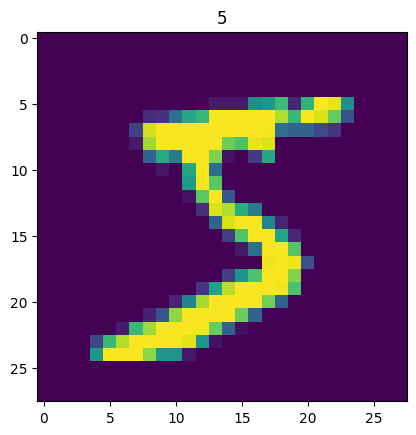

In [20]:
import matplotlib.pyplot as plt
mnist_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
for image, label in mnist_dataset:
    plt.title(label.numpy())
    plt.imshow(image.numpy())
    plt.show()
    break

#### 5）Python generator(旧) 和 image_dataset_from_directory(推荐) 构建数据管道 
- from_generator() 方法接受一个可调用的生成器函数作为参数，在遍历Dataset对象时，通过通用生成器函数继续生成新的数据供训练和测试模型使用，这在大数据集合中很实用。

- 但是旧版 ImageDataGenerator + from_generator 的方式依赖额外库（如 scipy）且性能有限，TensorFlow 2.x 官方推荐直接使用 tf.keras.utils.image_dataset_from_directory 加载目录数据，配合 tf.keras.layers 预处理层 实现数据增强。这种方式无需自定义生成器、不依赖第三方库、预处理层可直接嵌入模型实现端到端推理，是大数据集的首选方案。

In [23]:
# img_gen = tf.keras.preprocessing.image.ImageDataGenerator(rescale = 1./255, rotation_range = 20)
# flowers = './Dataset/flower_photos'

# def Gen():
#     gen = img_gen.flow_from_directory(flowers, batch_size = 8)
#     for (x, y) in gen:
#         yield (x, y)

In [24]:
# ds = tf.data.Dataset.from_generator(Gen, output_types = (tf.float32, tf.float32)) #构造数据集
# for image, label in ds:
#     print(image.shape, label.shape)
#     break

image_dataset_from_directory

In [26]:
batch_size = 8
img_height = 256  # 根据实际图片尺寸调整
img_width = 256
flowers_dir = './Dataset/flower_photos'

# 直接从目录加载数据集（替代旧版 flow_from_directory）
# 自动按子文件夹划分类别，返回 (image, label) 格式的 tf.data.Dataset
ds = tf.keras.utils.image_dataset_from_directory(
    flowers_dir,
    image_size=(img_height, img_width),  # 统一图片尺寸
    batch_size=batch_size,
    label_mode='categorical',
    shuffle=True,  # 自动打乱数据
    seed=123
)

# 定义数据增强层（替代旧版 ImageDataGenerator，可直接嵌入模型）
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),  # 对应旧版 rescale=1./255
    tf.keras.layers.RandomRotation(0.2)  # 对应旧版 rotation_range=20（参数为比例，0.2即20度）
])

# 应用数据增强到数据集
ds = ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE  # 自动并行处理，提升性能
)

# 测试遍历数据集
for image, label in ds:
    print(image.shape, label.shape)
    break

Found 3670 files belonging to 5 classes.
(8, 256, 256, 3) (8, 5)


### tf.data.TFRecordDataset
#### 1）tf.data.TFRecordDataset简介
对于特别巨大而无法完整载入内存的数据集，我们可以先将数据集处理为TFRecord 格式，然后使用 tf.data.TFRecordDataset() 进行载入。

TFRecord 是 TensorFlow 中的数据集存储格式。当我们将数据集整理成TFRecord 格式后，TensorFlow 就可以高效地读取和处理这些数据集，从而帮助我们更高效地进行大规模的模型训练。

实际上，TFRecord是一种二进制文件，其能更好的利用内存，其内部包含了多个tf.train.Example ， 而Example是protocol buffer数据标准的实现，在一个Example消息体中包含了一系列的 tf.train.feature 属性，而 每一个feature 是一个key-value的键值对，其中，key是string类型，而value 的取值有三种：

- bytes_list: 可以存储string和byte两种数据类型。

- float_list: 可以存储float(float32 ) 与double(float64 ) 两种数据类型 。

- int64_list : 可以存储：bool, enum, int32 , uint32 , int64 , uint64 。

#### 2）TFRecord格式
TFRecord 可以理解为一系列序列化的tf.train .Example 元素所组成的列表文件，而每一个 tf.train.Exa mple 又由若干个 tf.train. Feature 的字典组成。

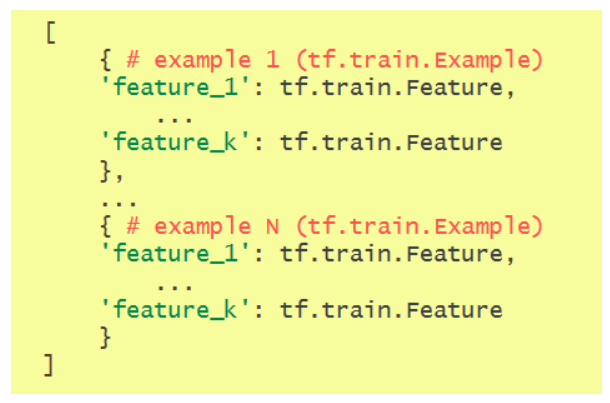

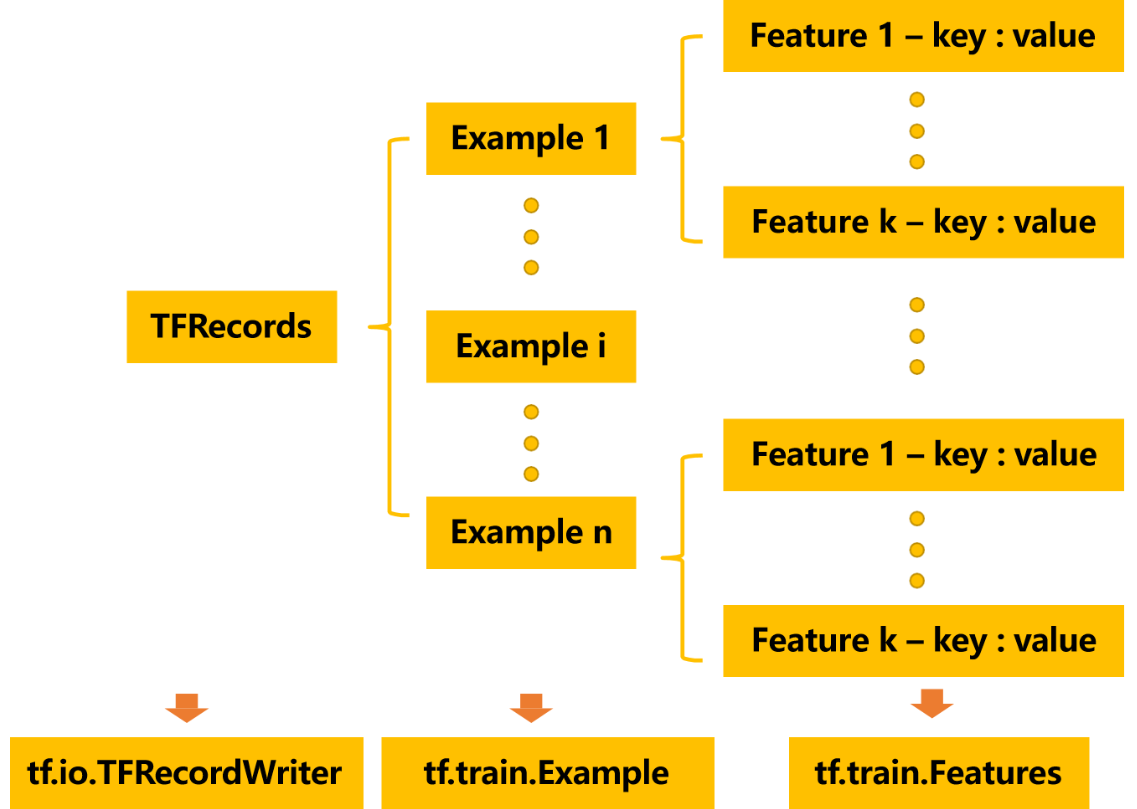

#### 3）生成TFRecord格式数据
为了将形式各样的数据集整理为 TFRecord 格式，我们可以对数据集中的每个元素进行以下步骤：

- 读取该数据元素到内存；
- 建立 Feature 的字典；
- 将该元素转换为 tf.train.Example 对象（每一个 tf.train.Example 由若干个tf.train.Feature 的字典组成）；
- 将该 tf.train.Example 对象序列化为字符串，并通过一个预先定义的tf.io.TFRecordWriter 写入 TFRecord 文件。

In [54]:
import os 
data_dir = 'Dataset/datasets'


train_cats_dir = data_dir + '/train/cats/'
train_dogs_dir = data_dir + '/train/dogs/'
train_tfrecord_file = data_dir + '/train/train.tfrecords'

test_cats_dir = data_dir + '/valid/cats/'
test_dogs_dir = data_dir + '/valid/dogs/'
test_tfrecord_file = data_dir + '/valid/test.tfrecords'

In [35]:
train_cat_filenames = [train_cats_dir + filename for filename in os.listdir(train_cats_dir)]#获取所有图片的路径
train_dog_filenames = [train_dogs_dir + filename for filename in os.listdir(train_dogs_dir)]
train_filenames = train_cat_filenames + train_dog_filenames#两个类别合并

# 将 cat 类的标签设为0，dog 类的标签设为1 
train_labels = [0] * len(train_cat_filenames) + [1] * len(train_dog_filenames) 

with tf.io.TFRecordWriter(train_tfrecord_file) as writer: # 构建writer
    for filename, label in zip(train_filenames, train_labels): # 读取数据集图片到内存，image 为一个 Byte 类型的字符串
        # 这里正式是建议使用opencv读取图片为ndarray再转成bytes，下面这个方法，读的时候还需要解码，耗时过长
        image = open(filename, 'rb').read() 
        feature = { # 建立 tf.train.Feature 字典
            'image': tf.train.Feature(bytes_list = tf.train.BytesList(value = [image])), # 图片是一个Bytes对象
            'label': tf.train.Feature(int64_list = tf.train.Int64List(value = [label])) # 标签是一个Int对象
        }

        example = tf.train.Example(features = tf.train.Features(feature = feature)) # 通过字典建立Example
        writer.write(example.SerializeToString()) # 将Example序列化写入 TFRecord文件

##### 写入 TFRecord（使用 OpenCV 预处理）

In [52]:
!pip install "opencv-python-headless<4.10"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 22.1 MB/s eta 0:00:00m eta 0:00:010:00:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92

[notice] A new release of pip is available: 23.3.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [55]:
import cv2

train_cat_filenames = [train_cats_dir + filename for filename in os.listdir(train_cats_dir)]
train_dog_filenames = [train_dogs_dir + filename for filename in os.listdir(train_dogs_dir)]
train_filenames = train_cat_filenames + train_dog_filenames

train_labels = [0] * len(train_cat_filenames) + [1] * len(train_dog_filenames)

with tf.io.TFRecordWriter(train_tfrecord_file) as writer:
    for filename, label in zip(train_filenames, train_labels):
        # -----核心修改
        # 使用 OpenCV 读取图片 (默认读取为 BGR 格式的 numpy ndarray)
        img = cv2.imread(filename)
        if img is None:
            continue # 跳过损坏或路径错误的图片
        # 转换通道: BGR 转 RGB (TensorFlow 和 matplotlib 默认使用 RGB)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # 提前 Resize: 原生像素数组非常占空间，强烈建议在写入前统一尺寸
        img = cv2.resize(img, (256, 256))
        # 将 numpy 数组转为 bytes (不再是 JPEG 编码的 bytes，而是纯像素 bytes)
        image_bytes = img.tobytes()

        feature = {
            'image': tf.train.Feature(bytes_list=tf.train.BytesList(value=[image_bytes])),
            'label': tf.train.Feature(int64_list=tf.train.Int64List(value=[label]))
        }
        example = tf.train.Example(features=tf.train.Features(feature=feature))
        writer.write(example.SerializeToString())

#### 4）读取TFRecord文件
读取 TFRecord 数据则可按照以下步骤：

- 通过 tf.data.TFRecordDataset 读入原始的 TFRecord 文件（此时文件中的tf.train.Example 对象尚未被反序列化），获得一个 tf.data.Dataset 数据集对象；
- 定义 Feature 结构，告诉解码器每个 Feature 的类型是什么；
- 通过 Dataset.map 方法，对该数据集对象中的每一个序列化的 tf.train.Example 字符串执行 tf.io.parse_single_example 函数，从而实现反序列化

TFRecordDataset参数详解

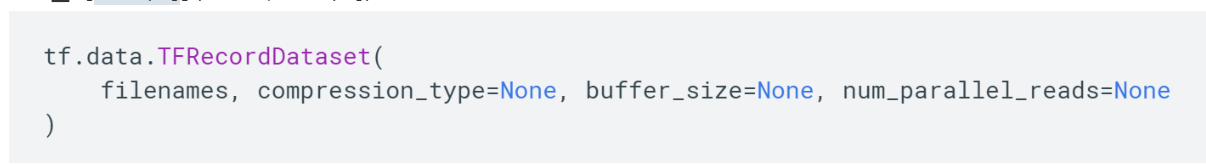

- filenames：tf.string张量，值为一个或多个文件名。
- compression_type：tf.string标量，值为 “”（不压缩）、"ZLIB"或"GZIP"之一。
- buffer_size：tf.int64标量，表示读取缓冲区中的字节数。
- num_parallel_reads：tf.int64标量，表示要并行读取的文件数。

In [56]:
train_dataset = tf.data.TFRecordDataset(train_tfrecord_file) # 定义TFRecord数据集

In [57]:
# 定义Feature结构，告诉解码器每个Feature的类型是什么
feature_description = {
    'image': tf.io.FixedLenFeature([], tf.string),
    'label': tf.io.FixedLenFeature([], tf.int64)
}

In [47]:
# 定义解析函数 将 TFRecord 文件中的每一个序列化的 tf.train.Example 解码
def _parse_example(example_string):
    feature_dict = tf.io.parse_single_example(example_string, feature_description)
    feature_dict['image'] = tf.io.decode_jpeg(feature_dict['image']) # 解码JPEG图片  这一步会耗时
    feature_dict['image'] = tf.image.resize(feature_dict['image'], [256, 256]) / 255.0 # 预处理x
    return feature_dict['image'], feature_dict['label']

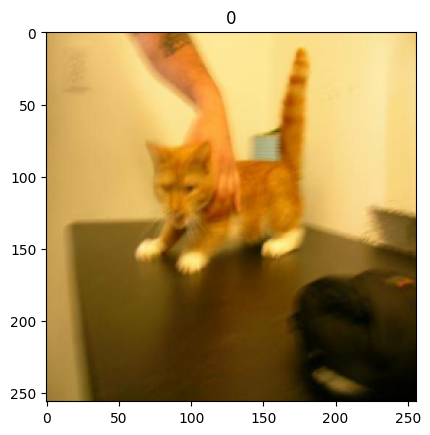

In [48]:
train_dataset = train_dataset.map(_parse_example)

for image, label in train_dataset:
    plt.title(label.numpy())
    plt.imshow(image.numpy())
    plt.show()
    break

##### OpenCV版本，可以大幅增加这个在线执行的步骤的效率

In [58]:
def _parse_example(example_string):
    feature_dict = tf.io.parse_single_example(example_string, feature_description)
    # 【关键修改】此时存入的已经是纯像素 bytes，不能用 decode_jpeg，必须用 decode_raw
    # 注意 out_type 必须与原本 numpy 数组的类型一致 (OpenCV 默认 uint8)
    image = tf.io.decode_raw(feature_dict['image'], out_type = tf.uint8)

    # 恢复形状: decode_raw 解析出的是一维张量，需要 reshape 回写入时的尺寸
    image = tf.reshape(image, [256, 256, 3])

    # 类型转换与归一化
    image = tf.cast(image, tf.float32) / 255.0
    label = feature_dict['label']

    return image, label

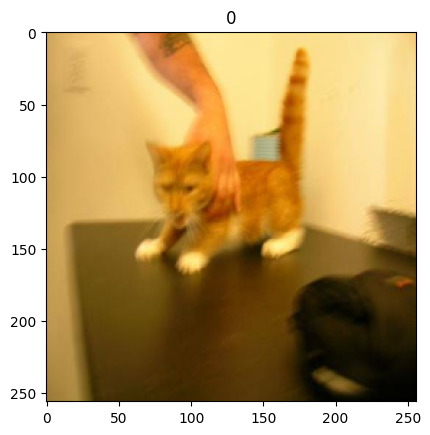

In [59]:
train_dataset = train_dataset.map(_parse_example)

for image, label in train_dataset:
    plt.title(str(label.numpy()))
    plt.imshow(image.numpy())
    plt.show()
    break

#### 5）tf.data.TextLineDataset
- tf.data.TextLineDataset 提供了一种从一个或多个文本文件中提取行的简单方法。
- 给定一个或多个文件名，TextLineDataset 会为这些文件的每行生成一个字符串值元素。像 TFRecordDataset 一样，TextLineDataset 将 filenames 视为 tf.Tensor。
- 类中保存的元素：文中一行，就是一个元素，是string类型的tensor。

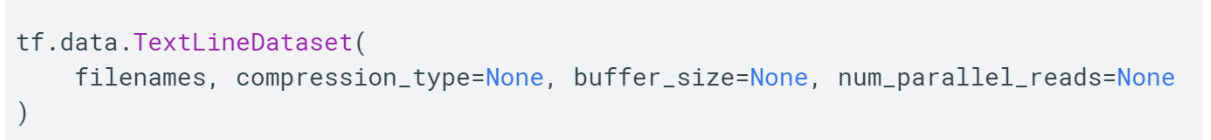

- filenames：tf.string张量，值为一个或多个文件名。
- compression_type：tf.string标量，值为 “”（不压缩）、"ZLIB"或"GZIP"之一。
- buffer_size：tf.int64标量，表示读取缓冲区中的字节数。
- num_parallel_reads：tf.int64标量，表示要并行读取的文件数

In [60]:
titanic_lines = tf.data.TextLineDataset(['Dataset/train.csv', 'Dataset/eval.csv'])
def data_func(line):
    line = tf.strings.split(line, sep = ',')
    return line
titanic_data = titanic_lines.skip(1).map(data_func)
for line in titanic_data:
    print(line)
    break

tf.Tensor(
[b'0' b'male' b'22.0' b'1' b'0' b'7.25' b'Third' b'unknown' b'Southampton'
 b'n'], shape=(10,), dtype=string)


### tf.data功能函数
#### 1）take()
功能：用于返回一个新的Dataset对象，新的Dataset对象包含的数据是原Dataset对象的子集。

参数：

- count：整型，用于指定前count条数据用于创建新的Dataset对象，如果count为-1或大于原Dataset对象的size,则用原Dataset对象的全部数据创建新的对象。

In [61]:
dataset = tf.data.Dataset.range(10)
dataset_take = dataset.skip(2).take(5)

In [62]:
for i in dataset_take:
    print(i)

tf.Tensor(2, shape=(), dtype=int64)
tf.Tensor(3, shape=(), dtype=int64)
tf.Tensor(4, shape=(), dtype=int64)
tf.Tensor(5, shape=(), dtype=int64)
tf.Tensor(6, shape=(), dtype=int64)


#### 2）***batch()***
功能：将Dataset中连续的数据分割成批。

参数：

- batch_size：在单个批次中合并的此数据集的连续元素数。

- drop_remainder：如果最后一批的数据量少于指定的batch_size，是否抛弃最后一批，默认为False，表示不抛弃。

In [72]:
dataset = tf.data.Dataset.range(11)
dataset_batch = dataset.batch(3)

In [73]:
for i in dataset_batch:
    print(i)

tf.Tensor([0 1 2], shape=(3,), dtype=int64)
tf.Tensor([3 4 5], shape=(3,), dtype=int64)
tf.Tensor([6 7 8], shape=(3,), dtype=int64)
tf.Tensor([ 9 10], shape=(2,), dtype=int64)


In [74]:
len(dataset_batch), len(dataset)

(4, 11)

In [75]:
dataset_batch = dataset.batch(3, drop_remainder = True)
for i in dataset_batch:
    print(i)

tf.Tensor([0 1 2], shape=(3,), dtype=int64)
tf.Tensor([3 4 5], shape=(3,), dtype=int64)
tf.Tensor([6 7 8], shape=(3,), dtype=int64)


#### 3）padded_batch()
功能：batch()的进阶版，可以对shape不一致的连续元素进行分批。

参数：

- batch_size：在单个批次中合并的此数据集的连续元素个数。

- padded_shapes：tf.TensorShape或其他描述tf.int64矢量张量对象，表示在批处理之前每个输入元素的各个组件应填充到的形状。如果参数中有None，则表示将填充为每个批次中该尺寸的最大尺寸。

- padding_values：要用于各个组件的填充值。默认值0用于数字类型，字符串类型则默认为空字符。

- drop_remainder：如果最后一批的数据量少于指定的batch_size，是否抛弃最后一批，默认为False，表示不抛弃。

In [77]:
dataset = tf.data.Dataset.range(10)
dataset = dataset.map(lambda x: tf.fill([tf.cast(x, tf.int32)], x)) # 先转换成x数值，再根据x值去填充
dataset_padded = dataset.padded_batch(4, padded_shapes = (None,)) # pad为每个批次最大的尺寸
for batch in dataset_padded:
    print(batch.numpy())
    print('----------------------')

[[0 0 0]
 [1 0 0]
 [2 2 0]
 [3 3 3]]
----------------------
[[4 4 4 4 0 0 0]
 [5 5 5 5 5 0 0]
 [6 6 6 6 6 6 0]
 [7 7 7 7 7 7 7]]
----------------------
[[8 8 8 8 8 8 8 8 0]
 [9 9 9 9 9 9 9 9 9]]
----------------------


In [79]:
dataset_padded = dataset.padded_batch(4, padded_shapes = (10,), padding_values = tf.constant(9, dtype = tf.int64)) # 修改填充形状和填充元素

for batch in dataset_padded:
    print(batch.numpy())
    print('-------------------------')

[[9 9 9 9 9 9 9 9 9 9]
 [1 9 9 9 9 9 9 9 9 9]
 [2 2 9 9 9 9 9 9 9 9]
 [3 3 3 9 9 9 9 9 9 9]]
-------------------------
[[4 4 4 4 9 9 9 9 9 9]
 [5 5 5 5 5 9 9 9 9 9]
 [6 6 6 6 6 6 9 9 9 9]
 [7 7 7 7 7 7 7 9 9 9]]
-------------------------
[[8 8 8 8 8 8 8 8 9 9]
 [9 9 9 9 9 9 9 9 9 9]]
-------------------------


#### 4）**map()**
功能：以dataset中每一位元素为参数执行pap_func()方法，这一功能在数据预处理中修改dataset中元素是很实用。

参数：

- map_func:回调方法。

In [80]:
def change_dtype(t):
    return tf.cast(t, dtype=tf.int32)

dataset = tf.data.Dataset.range(3)

for i in dataset:
    print(i)

tf.Tensor(0, shape=(), dtype=int64)
tf.Tensor(1, shape=(), dtype=int64)
tf.Tensor(2, shape=(), dtype=int64)


In [81]:
dataset_map = dataset.map(change_dtype)

for i in dataset_map:
    print(i)

tf.Tensor(0, shape=(), dtype=int32)
tf.Tensor(1, shape=(), dtype=int32)
tf.Tensor(2, shape=(), dtype=int32)


map_func的参数必须对应dataset中的元素类型，例如，如果dataset中元素是tuple，map_func可以这么定义：

In [82]:
def change_dtype_2(t1, t2):
    return t1 / 10, tf.cast(t2, dtype = tf.int32) * (-1) # 第一位元素除以10， 第二位元素乘以-1

In [85]:
dataset = tf.data.Dataset.from_tensor_slices((tf.range(3), tf.range(3)))
dataset_map = dataset.map(change_dtype_2)

for i in dataset_map:
    print(i)

(<tf.Tensor: shape=(), dtype=float64, numpy=0.0>, <tf.Tensor: shape=(), dtype=int32, numpy=0>)
(<tf.Tensor: shape=(), dtype=float64, numpy=0.1>, <tf.Tensor: shape=(), dtype=int32, numpy=-1>)
(<tf.Tensor: shape=(), dtype=float64, numpy=0.2>, <tf.Tensor: shape=(), dtype=int32, numpy=-2>)


#### 5）filter()
功能：对Dataset中每一个执行指定过滤方法进行过滤，返回过滤后的Dataset对象

参数：

- predicate：过滤方法，返回值必须为True或False

In [86]:
dataset = tf.data.Dataset.range(5)

def filter_func(t): # 过滤出值为偶数的元素
    if t % 2 == 0:
        return True
    else:
        return False
    
dataset_filter = dataset.filter(filter_func)

for i in dataset_filter:
    print(i)

tf.Tensor(0, shape=(), dtype=int64)
tf.Tensor(2, shape=(), dtype=int64)
tf.Tensor(4, shape=(), dtype=int64)


#### ***6）shuffle()***
功能：随机打乱数据

参数：

- buffer_size：缓冲区大小，姑且认为是混乱程度吧，当值为1时，完全不打乱，当值为整个Dataset元素总数时，完全打乱。
- seed：将用于创建分布的随机种子。
- reshuffle_each_iteration：如果为true，则表示每次迭代数据集时都应进行伪随机重排，默认为True。

In [87]:
dataset = tf.data.Dataset.range(5)

dataset_s = dataset.shuffle(3)

for i in dataset_s:
    print(i)

tf.Tensor(2, shape=(), dtype=int64)
tf.Tensor(0, shape=(), dtype=int64)
tf.Tensor(3, shape=(), dtype=int64)
tf.Tensor(4, shape=(), dtype=int64)
tf.Tensor(1, shape=(), dtype=int64)


In [90]:
dataset_s = dataset.shuffle(5)

for i in dataset_s:
    print(i)

tf.Tensor(4, shape=(), dtype=int64)
tf.Tensor(3, shape=(), dtype=int64)
tf.Tensor(0, shape=(), dtype=int64)
tf.Tensor(1, shape=(), dtype=int64)
tf.Tensor(2, shape=(), dtype=int64)


#### 7）repeat()
功能：对Dataset中的数据进行重复，以创建新的Dataset

参数：

- count：重复次数，默认为None，表示不重复，当值为-1时，表示无限重复。

In [92]:
dataset = tf.data.Dataset.range(3)

dataset_repeat = dataset.repeat(3)

for i in dataset_repeat: #通过数据集的重复来实现多epochs训练
    print(i)

tf.Tensor(0, shape=(), dtype=int64)
tf.Tensor(1, shape=(), dtype=int64)
tf.Tensor(2, shape=(), dtype=int64)
tf.Tensor(0, shape=(), dtype=int64)
tf.Tensor(1, shape=(), dtype=int64)
tf.Tensor(2, shape=(), dtype=int64)
tf.Tensor(0, shape=(), dtype=int64)
tf.Tensor(1, shape=(), dtype=int64)
tf.Tensor(2, shape=(), dtype=int64)


In [93]:
dataset = tf.data.Dataset.range(3)

for epoch in range(3):
    print("##### ", epoch)
    for i in dataset:
        print(i)


#####  0
tf.Tensor(0, shape=(), dtype=int64)
tf.Tensor(1, shape=(), dtype=int64)
tf.Tensor(2, shape=(), dtype=int64)
#####  1
tf.Tensor(0, shape=(), dtype=int64)
tf.Tensor(1, shape=(), dtype=int64)
tf.Tensor(2, shape=(), dtype=int64)
#####  2
tf.Tensor(0, shape=(), dtype=int64)
tf.Tensor(1, shape=(), dtype=int64)
tf.Tensor(2, shape=(), dtype=int64)


### 经典数据集加载
#### 1）tf.keras.datasets简介
在 TensorFlow 中，keras.datasets 模块提供了常用经典数据集的自动下载、管理、加载与转换功能，并且提供了 tf.data.Dataset 数据集对象，方便实现多线程(Multi-thread)，预处理(Preprocess)，随机打散(Shuffle)和批训练(Train on batch)等常用数据集功能。

对于常用的数据集，如：

- ❑ Boston Housing 波士顿房价趋势数据集，用于回归模型训练与测试

- ❑ CIFAR10/100 真实图片数据集，用于图片分类任务

- ❑ MNIST/Fashion_MNIST 手写数字图片数据集，用于图片分类任务

- ❑ IMDB 情感分类任务数据集

这些数据集在机器学习、深度学习的研究和学习中使用的非常频繁。对于新提出的算法，一般优先在简单的数据集上面测试，再尝试迁移到更大规模、更复杂的数据集上。

通过 datasets.xxx.load_data()即可实现经典数据集的自动加载，其中 xxx 代表具体的数据集名称。TensorFlow 会默认将数据缓存在用户目录下的.keras/datasets 文件夹，如图所示，用户不需要关心数据集是如何保存的。如果当前数据集不在缓存中，则会自动从网站下载和解压，加载；如果已经在缓存中，自动完成加载：

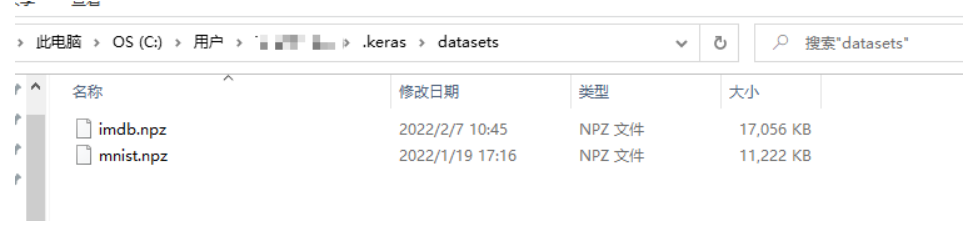

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets 
# MNIST
(x, y), (x_test, y_test) = datasets.mnist.load_data()
print('x:', x.shape, 'y:', y.shape, 'x_test:', x_test.shape, 'y_test:', y_test)

2026-04-04 14:07:52.917488: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-04 14:07:52.917670: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-04 14:07:52.986458: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


x: (60000, 28, 28) y: (60000,) x_test: (10000, 28, 28) y_test: [7 2 1 ... 4 5 6]


通过 load_data()会返回相应格式的数据，对于图片数据集 MNIST, CIFAR10 等，会返回 2 个 tuple：

- 第一个 tuple 保存了用于训练的数据 x,y 训练集对象；

- 第 2 个 tuple 则保存了用于测试的数据 x_test,y_test 测试集对象，所有的数据都用 Numpy.array 容器承载。

数据加载进入内存后，需要转换成 Dataset 对象，以利用 TensorFlow 提供的各种便捷功能。通过 Dataset.from_tensor_slices 可以将训练部分的数据图片 x 和标签 y 都转换成Dataset 对象

将数据转换成 Dataset 对象后，一般需要再添加一系列的数据集标准处理步骤，如随机打散，预处理，按批装载等。

In [2]:
train_db = tf.data.Dataset.from_tensor_slices((x, y))

2026-04-04 14:10:38.251748: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.


#### 2）随机打散
通过 Dataset.shuffle(buffer_size) 工具可以设置 Dataset 对象随机打散数据之间的顺序，防止每次训练时数据按固定顺序产生，从而使得模型尝试“记忆”住标签信息：

其中 buffer_size 指定缓冲池的大小，一般设置为一个较大的参数即可。通过 Dataset 提供的这些工具函数会返回新的 Dataset 对象，可以通过

db = db. shuffle(). step2(). step3. ()

方式完成所有的数据处理步骤，实现起来非常方便。

In [3]:
train_db = train_db.shuffle(10000)

#### 3）批训练
为了利用显卡的并行计算能力，一般在网络的计算过程中会同时计算多个样本，我们把这种训练方式叫做批训练，其中样本的数量叫做 batch size。为了一次能够从 Dataset 中产生 batch size 数量的样本，需要设置 Dataset 为批训练方式：

In [4]:
train_db = train_db.batch(128)

其中 128 为 batch size 参数，即一次并行计算 128 个样本的数据。Batch size 一般根据用户的 GPU 显存资源来设置，当显存不足时，可以适量减少 batch size 来减少算法的显存使用量。

#### 4）预处理
从 keras.datasets 中加载的数据集的格式大部分情况都不能满足模型的输入要求，因此需要根据用户的逻辑自己实现预处理函数。Dataset 对象通过提供 map(func) 工具函数可以非常方便地调用用户自定义的预处理逻辑，它实现在 func 函数里：

train_db = train_db.map(preprocess) #预处理函数实现在 preprocess 函数中，传入函数引用即可

考虑 MNIST 手写数字图片，从 keras.datasets 中经.batch()后加载的图片 x shape 为 [b, 28,28]，像素使用 0~255 的整形表示；标注 shape 为[b]，即采样的数字编码方式。实际的神经网络输入，一般需要将图片数据标准化到[0,1]或[−1,1]等 0 附近区间，同时根据网络的设置，需要将 shape [28,28] 的输入 Reshape 为合法的格式；对于标注信息，可以选择在预处理时进行 one-hot 编码，也可以在计算误差时进行 one-hot 编码。

根据下一节的实战设定，我们将 MNIST 图片数据映射到x ∈ [0,1]区间，视图调整为[b, 28 ∗ 28]；对于标注 y，我们选择在预处理函数里面进行 one-hot 编码：

In [5]:
#train_db.map(func).shuffle(1000).batch(128)  传递给func的是一个样本的x和y
#train_db.shuffle(1000).batch(128).map(func) 传递给func的是一个批次b个样本的x和y

def preprocess(x, y):# 自定义的预处理函数 **此时传入的是一个批次的x y**
    # 调用此函数时会自动传入 x,y 对象，shape 为[b, 28, 28], [b]
    # 标准化到 0~1
    x = tf.cast(x, dtype = tf.float32) / 255.
    x = tf.reshape(x, [-1, 28*28]) # 打平
    y = tf.cast(y, dtype=tf.int32) # 转成整形张量 
    y = tf.one_hot(y, depth=10) # one-hot 编码
    # 返回的 x,y 将替换传入的 x,y 参数，从而实现数据的预处理功能
    return x,y

# 预处理函数实现在 preprocess 函数中，传入函数引用即可
train_db = train_db.map(preprocess)

5）循环训练
对于 Dataset 对象，在使用时可以通过以下两种仿真丝进行循环训练：

- for step, (x,y) in enumerate(train_db): # 迭代数据集对象，带 step 参数
- for x,y in train_db: # 迭代数据集对象

每次返回的 x,y 对象即为批量样本和标签，当对 train_db 的所有样本完成一次迭代后，for 循环终止退出。

step和epoch：

- 我们一般把完成一个 batch 的数据训练，叫做一个 step；
- 通过多个 step 来完成整个训练集的一次迭代，叫做一个 epoch。

在实际训练时，通常需要对数据集迭代 多个 epoch 才能取得较好地训练效果：

In [ ]:
#1.循环迭代epoch
for epoch in range(20): # 训练 Epoch 数
    for step, (x, y) in enumerate(train_db): # 迭代 Step 数
        pass # training... 计算损失 更新参数

#2.设置数据集重复实现epoch迭代
train_db = train_db.repeat(20) # 数据集迭代 20 遍才终止

### 加载自定义数据集实战
在加载数据和预处理数据时使用tf.data.Dataset对象将极大将我们从建模前的数据清理工作中释放出来，那么，怎么将自定义的数据集加载为DataSet对象呢？这对很多新手来说都是一个难题，因为绝大多数案例教学都是以mnist数据集作为例子讲述如何将数据加载到Dataset中，而英文资料对这方面的介绍隐藏得有点深。

#### 1）下载数据
如果已有数据集，那么，请将所有数据存放在同一目录下，然后将不同类别的图片分门别类地存放在不同的子目录下,目录树如下所示：

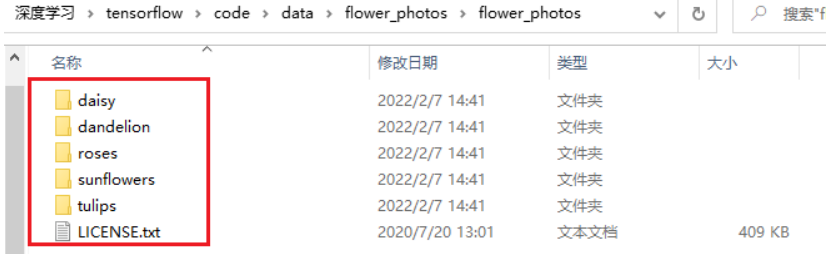

所有的数据都存放在flower_photos目录下，每一个子目录（daisy、dandelion等等）存放的都是一个类别的图片。

如果你已有自己的数据集，那就按上面的结构来存放，如果没有，可以通过下面代码下载上述图片数据集：

In [9]:
import tensorflow as tf
import pathlib

data_root_orig = tf.keras.utils.get_file(origin = 'https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz',
                                         fname = 'flower_photos', untar = True)
data_root = pathlib.Path(data_root_orig)
print(data_root) # 打印出数据集所在目录

228813984/228813984 [==============================] - 18s 0us/step
/root/.keras/datasets/flower_photos


#### 2）加载图片路径

In [12]:
import random
data_path = pathlib.Path('./Dataset/flower_photos')
all_image_paths = list(data_path.glob('*/*'))
all_image_paths = [str(path) for path in all_image_paths] # 所有图片路径的列表
random.shuffle(all_image_paths) # 打散

image_count = len(all_image_paths)
image_count

3670

In [13]:
all_image_paths[:5]

['Dataset/flower_photos/daisy/14674743211_f68b13f6d9.jpg',
 'Dataset/flower_photos/roses/326541992_d542103ca8_n.jpg',
 'Dataset/flower_photos/roses/3713368809_eba7fa2fbf_m.jpg',
 'Dataset/flower_photos/daisy/9094631844_1a6abca29e.jpg',
 'Dataset/flower_photos/daisy/2561352120_7961d8263f.jpg']

#### 3）加载标签
读取图片的同时，我们也不能忘记图片与标签的对应，要创建一个对应的列表来存放图片标签，不过，这里所说的标签不是daisy、dandelion这些具体分类名，而是整型的索引，毕竟在建模的时候y值一般都是整型数据，所以要创建一个字典来建立分类名与标签的对应关系：

In [15]:
label_names = sorted(item.name for item in data_path.glob('*/') if item.is_dir())
label_names

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

In [22]:
label_to_index = dict((name, index) for index, name in enumerate(label_names))
label_to_index

{'daisy': 0, 'dandelion': 1, 'roses': 2, 'sunflowers': 3, 'tulips': 4}

In [23]:
all_image_labels = [label_to_index[pathlib.Path(path).parent.name] for path in all_image_paths]

for image, label in zip(all_image_paths[:5], all_image_labels[:5]):
    print(image, '--->', label)

Dataset/flower_photos/daisy/14674743211_f68b13f6d9.jpg ---> 0
Dataset/flower_photos/roses/326541992_d542103ca8_n.jpg ---> 2
Dataset/flower_photos/roses/3713368809_eba7fa2fbf_m.jpg ---> 2
Dataset/flower_photos/daisy/9094631844_1a6abca29e.jpg ---> 0
Dataset/flower_photos/daisy/2561352120_7961d8263f.jpg ---> 0


#### 4）创建Dataset

In [24]:
ds = tf.data.Dataset.from_tensor_slices((all_image_paths, all_image_labels))

但是，这个ds可不是我们想要的，毕竟，里面的元素只是图片路径，所以我们要进一步处理。这个处理包含读取图片、重新设置图片大小、归一化、转换类型等操作，我们将这些操作统统定义到一个方法里：

In [25]:
#定义预处理方法  
def load_and_preprocess_from_path_label(path, label):
    image = tf.io.read_file(path)  # 读取图片
    image = tf.image.decode_jpeg(image, channels=3)#jpeg解码
    image = tf.image.resize(image, [150, 150])  # 原始图片大小为(266, 320, 3)，重设为(150, 150，3)
    image /= 255.0  # 归一化到[0,1]范围   【-1，1】
    return image, label

In [26]:
image_label_ds = ds.map(load_and_preprocess_from_path_label)
image_label_ds

<_MapDataset element_spec=(TensorSpec(shape=(150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int32, name=None))>

至此，我们已经将自定义的图片数据集加载到了Dataset对象中，不过，我们还可以继续shuffle随机打散、分割成batch、数据repeat操作。这些操作有几点需要注意：

- （1）shuffle、repeat、batch三种操作顺序有讲究：

    - 在repeat之后shuffle，会在epoch之间数据随机（当有些数据出现两次的时候，其他数据还没有出现过）
    - 在batch之后shuffle，会打乱batch的顺序，但是不会在batch之间打乱数据。
    
- （2）shuffle操作时，buffer_size越大，打乱效果越好，但消耗内存越大，可能造成延迟。

推荐通过使用 tf.data.Dataset.apply 方法和融合过的 tf.data.experimental.shuffle_and_repeat 函数来执行这些操作:

In [27]:
ds = image_label_ds.apply(tf.data.experimental.shuffle_and_repeat(buffer_size = image_count))
BATCH_SIZE = 32
ds = ds.batch(BATCH_SIZE)

Instructions for updating:
Use `tf.data.Dataset.shuffle(buffer_size, seed)` followed by `tf.data.Dataset.repeat(count)`. Static tf.data optimizations will take care of using the fused implementation.


#### 5）改进
上面的方法是简单的在每次epoch迭代中单独读取每个文件，在本地使用 CPU 训练时这个方法是可行的，但是可能不足以进行GPU训练并且完全不适合任何形式的分布式训练。

可以使用 tf.data.Dataset.cache 在epoch迭代过程间缓存计算结果。这能极大提升程序效率，特别是当内存能容纳全部数据时。

在被预处理之后（解码和调整大小），图片就被缓存了：

In [28]:
ds = image_label_ds.cache() # 缓存  第一次遍历的时候打开图片并缓存到内存，第二次遍历不需要读取
ds = ds.apply(tf.data.experimental.shuffle_and_repeat(buffer_size = image_count))

使用内存缓存的一个缺点是必须在每次运行时重建缓存，这使得每次启动数据集时有相同的启动延迟。如果内存不够容纳数据，使用一个缓存文件：

In [ ]:
ds = image_label_ds.cache(filename='./cache.tf-data')
ds = ds.apply(tf.data.experimental.shuffle_and_repeat(buffer_size=image_count))